# Optimizing Delta V for Earth to Moon Orbits

- This Notebook is used to run an instance of the CR3BPSytsem class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cr3bp import create_earth_moon_system

%matplotlib inline

In [2]:
em = create_earth_moon_system()
#em.info()

In [3]:
state0 = np.array([0.8369, 0.0, 0.0, 0.0, 0.1, 0.0])

time = (0,6)
t_eval = np.linspace(0,6,1000)

In [4]:
states, times, sol = em.solve(state0, time,t_eval=t_eval)

### Plots

#### Rotating Frame

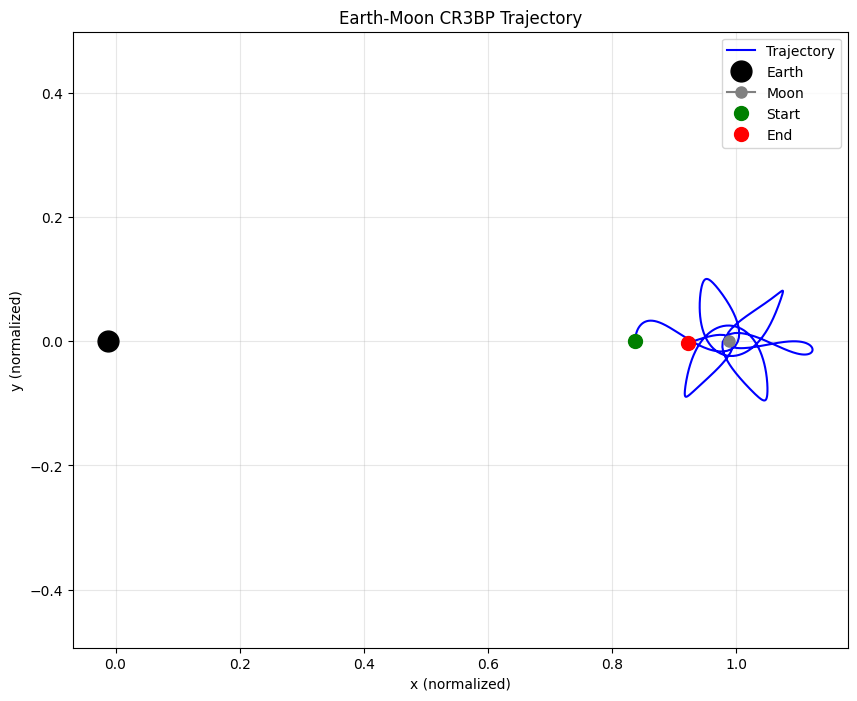

In [5]:
plt.figure(figsize=(10, 8))

# Plot trajectory
plt.plot(states[0, :], states[1, :], 'b-', linewidth=1.5, label='Trajectory')

# Plot primaries
plt.plot(-em.mu, 0, 'ko', markersize=15, label='Earth')
plt.plot(1-em.mu, 0, 'gray', marker='o', markersize=8, label='Moon')

# Plot start/end
plt.plot(state0[0], state0[1], 'go', markersize=10, label='Start')
plt.plot(states[0, -1], states[1, -1], 'ro', markersize=10, label='End')

plt.xlabel('x (normalized)')
plt.ylabel('y (normalized)')
plt.title('Earth-Moon CR3BP Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

#### Inertial Frame

In [6]:
states_inertial = em.trajectory_rotating_to_inertial(states, times)

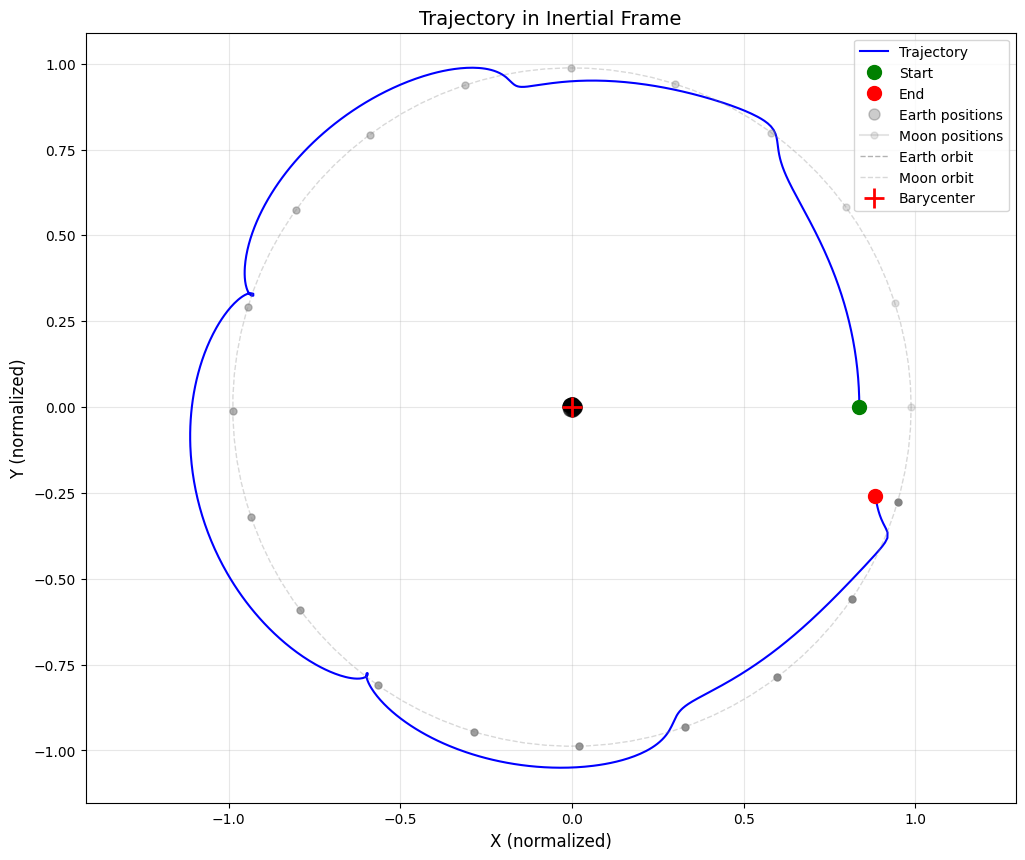

In [7]:
plt.figure(figsize=(12, 10))

# Plot trajectory in inertial frame
plt.plot(states_inertial[0, :], states_inertial[1, :], 
         'b-', linewidth=1.5, label='Trajectory')

# Plot start and end positions
plt.plot(states_inertial[0, 0], states_inertial[1, 0], 
         'go', markersize=10, label='Start')
plt.plot(states_inertial[0, -1], states_inertial[1, -1], 
         'ro', markersize=10, label='End')

# Plot Earth and Moon at multiple time snapshots to show rotation
n_snapshots = 20
snapshot_indices = np.linspace(0, len(times)-1, n_snapshots, dtype=int)

for i, idx in enumerate(snapshot_indices):
    t = times[idx]
    
    # Earth position (rotates around barycenter)
    earth_x = -em.mu * np.cos(t)
    earth_y = -em.mu * np.sin(t)
    
    # Moon position (rotates around barycenter)
    moon_x = (1 - em.mu) * np.cos(t)
    moon_y = (1 - em.mu) * np.sin(t)
    
    # Fade from light to dark as time progresses
    alpha = 0.2 + 0.8 * (i / n_snapshots)
    
    if i == 0:
        plt.plot(earth_x, earth_y, 'ko', markersize=8, alpha=alpha, label='Earth positions')
        plt.plot(moon_x, moon_y, 'gray', marker='o', markersize=5, alpha=alpha, label='Moon positions')
    else:
        plt.plot(earth_x, earth_y, 'ko', markersize=8, alpha=alpha)
        plt.plot(moon_x, moon_y, 'gray', marker='o', markersize=5, alpha=alpha)

# Plot Earth and Moon orbits
theta = np.linspace(0, 2*np.pi, 100)
earth_orbit_x = -em.mu * np.cos(theta)
earth_orbit_y = -em.mu * np.sin(theta)
moon_orbit_x = (1 - em.mu) * np.cos(theta)
moon_orbit_y = (1 - em.mu) * np.sin(theta)

plt.plot(earth_orbit_x, earth_orbit_y, 'k--', alpha=0.3, linewidth=1, label='Earth orbit')
plt.plot(moon_orbit_x, moon_orbit_y, 'gray', linestyle='--', alpha=0.3, linewidth=1, label='Moon orbit')

# Barycenter
plt.plot(0, 0, 'r+', markersize=15, markeredgewidth=2, label='Barycenter')

plt.xlabel('X (normalized)', fontsize=12)
plt.ylabel('Y (normalized)', fontsize=12)
plt.title('Trajectory in Inertial Frame', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()